# Проект. Исследование стартапов

## Введение

Исследование проводится **в целях** изучения закономерности финансирования стартапов и оценки перспективы выхода на рынок с покупкой и развитием компаний.

**Задачи:**

1. Загрузка и знакомство с данными
2. Проведение предобработки данных
3. Проведение инжениринга признаков
4. Работа с выбросами и анализ
5. Анализ динамики
6. Формирование выводов исследования и рекомендаций

## Знакомство с данными: загрузка и предобработка


### Датасет `cb_investments.csv`.

**Описание данных:**
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны.
* `state_code` — код штата.
* `region` — регион.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

### Датасет `cb_returns.csv`

**Описание данных:**
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

In [1]:
# Импорт всех библиотек
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
# Выгружаем данные в переменные investments_df и returns_df
investments_df = pd.read_csv("https://.../cb_investments.zip", sep=';', low_memory=False)
returns_df = pd.read_csv('https://.../cb_returns.csv')

In [3]:
# Выводим первые 5 строк датафрейма investments_df
investments_df.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Выводим общую информацию о датафрейме investments_df
investments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [5]:
# Выводим первые 5 строк датафрейма returns_df
returns_df.head()

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.0,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.0,0.20,0.0
1,2001,2.88,23.49,0.0,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.0,0.46,0.0
2,2002,6.59,209.42,0.0,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.0,0.06,0.0
3,2003,7.74,233.86,0.0,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.0,0.08,0.0
4,2004,9.93,555.90,0.0,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.0,0.55,0.0


In [6]:
# Выводим общую информацию о датафрейме returns_df
returns_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [7]:
# Изучаем количество пропусков в датафрейме в абсолютных значениях
investments_df.isna().sum()

name                     4857
homepage_url             8305
category_list            8817
 market                  8817
 funding_total_usd       4856
status                   6170
country_code            10129
state_code              24133
region                  10129
city                    10972
funding_rounds           4856
participants            23821
founded_at              15740
founded_month           15812
founded_quarter         15812
founded_year            15740
first_funding_at         4856
mid_funding_at          24006
last_funding_at          4856
seed                     4856
venture                  4856
equity_crowdfunding      4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_A                  4856
round_B   

In [8]:
# Изучаем количество пропусков в датафрейме в относительных значениях
investments_df.isna().mean()

name                    0.089457
homepage_url            0.152963
category_list           0.162394
 market                 0.162394
 funding_total_usd      0.089439
status                  0.113641
country_code            0.186558
state_code              0.444487
region                  0.186558
city                    0.202085
funding_rounds          0.089439
participants            0.438741
founded_at              0.289903
founded_month           0.291229
founded_quarter         0.291229
founded_year            0.289903
first_funding_at        0.089439
mid_funding_at          0.442148
last_funding_at         0.089439
seed                    0.089439
venture                 0.089439
equity_crowdfunding     0.089439
undisclosed             0.089439
convertible_note        0.089439
debt_financing          0.089439
angel                   0.089439
grant                   0.089439
private_equity          0.089439
post_ipo_equity         0.089439
post_ipo_debt           0.089439
secondary_

In [9]:
# Изучаем количество полных дубликатов в датафрейме
investments_df.duplicated().sum()

4855

Таким образом, первичный осмотор данных показал следующее:

Датасет **"cb_investments.csv"** содержит 54294 строк и 40 столбцов, включающих подробную информацию о компаниях-стартапах и состоявшемся финансировании. Первичный осмотр данных позволяет сделать следующие выводы:
- Названия большей части столбцов приведены в соответствие с правилами snake case, однако, в столбцах market и funding_total_usd есть лишние пробелы, столбцы round_A - round_H содержат заглавные буквы.
- Выявлены некорректные типы данных. В столбцах funding_total_usd данные относятся к категории object, хотя должны хранить числовой тип данных. Столбцы founded_at, founded_month, founded_quarter, first_funding_at, mid_funding_at, last_funding_at должны относиться к дате и времени.
- Пропуски содержаться во всех столбцах датасета.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.
- Количество дубликатов в датафрейме составляет 4855.

Датасет **"cb_returns.csv"** содержит 15 строк и 14 столбцов и включает информацию об объёмах возвратов по годам и типам финансирования. Первичный осмотр данных позволяет сделать следующие выводы:

- Названия столбцов приведены в соответствие с правилами snake case.
- Типы данных отражены корректно.
- Пропуски в датасете отсутствуют.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

### 1.2. Предобработка данных

In [10]:
# Делаем копии датафреймов для предобработки данных:
preprocessed_investments_df = investments_df.copy()
preprocessed_returns_df = returns_df.copy()

In [11]:
# Выводим названия столбцов датафрейма investments_df
preprocessed_investments_df.columns

Index(['name', 'homepage_url', 'category_list', ' market ',
       ' funding_total_usd ', 'status', 'country_code', 'state_code', 'region',
       'city', 'funding_rounds', 'participants', 'founded_at', 'founded_month',
       'founded_quarter', 'founded_year', 'first_funding_at', 'mid_funding_at',
       'last_funding_at', 'seed', 'venture', 'equity_crowdfunding',
       'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
       'private_equity', 'post_ipo_equity', 'post_ipo_debt',
       'secondary_market', 'product_crowdfunding', 'round_A', 'round_B',
       'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H'],
      dtype='object')

In [12]:
# Преобразуем названия всех столбцов к snake case
preprocessed_investments_df.columns = preprocessed_investments_df.columns.str.lower().str.replace(' ', '')

In [13]:
# Убераем разделение разрядов в столбце funding_total_usd
preprocessed_investments_df['funding_total_usd'] = preprocessed_investments_df['funding_total_usd'].str.replace(',', '')

In [14]:
# Приводим столбец funding_total_usd к числовому типу данных
preprocessed_investments_df['funding_total_usd'] = pd.to_numeric(preprocessed_investments_df['funding_total_usd'], 
                                                                 errors='coerce')

In [15]:
# Преобразуем значения к формату даты и времени
preprocessed_investments_df['founded_at'] = pd.to_datetime(preprocessed_investments_df['founded_at'], errors='coerce')
preprocessed_investments_df['founded_month'] = pd.to_datetime(preprocessed_investments_df['founded_month'], errors='coerce')
preprocessed_investments_df['founded_quarter'] = pd.to_datetime(preprocessed_investments_df['founded_quarter'], errors='coerce')
preprocessed_investments_df['first_funding_at'] = pd.to_datetime(preprocessed_investments_df['first_funding_at'], errors='coerce')
preprocessed_investments_df['mid_funding_at'] = pd.to_datetime(preprocessed_investments_df['mid_funding_at'], errors='coerce')
preprocessed_investments_df['last_funding_at'] = pd.to_datetime(preprocessed_investments_df['last_funding_at'], errors='coerce')

In [16]:
# Проверяем изменение типа данных
preprocessed_investments_df[['founded_at', 'founded_month', 'founded_quarter', 
                             'first_funding_at', 'mid_funding_at', 'last_funding_at']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   founded_at        38553 non-null  datetime64[ns]
 1   founded_month     38482 non-null  datetime64[ns]
 2   founded_quarter   38482 non-null  datetime64[ns]
 3   first_funding_at  49428 non-null  datetime64[ns]
 4   mid_funding_at    30288 non-null  datetime64[ns]
 5   last_funding_at   49432 non-null  datetime64[ns]
dtypes: datetime64[ns](6)
memory usage: 2.5 MB


In [17]:
# Определяем индекс датасета returns_df по столбцу year
preprocessed_returns_df = preprocessed_returns_df.set_index('year')

In [18]:
# Обрабатываем пропуски в текстовых данных
text_columns = ['name', 'category_list', 'market', 'status', 'country_code', 'state_code', 'region', 'city']
for col in text_columns:
    if col in preprocessed_investments_df.columns:
        if preprocessed_investments_df[col].isna().sum() > 0:
            preprocessed_investments_df[col] = preprocessed_investments_df[col].fillna('unknown')

In [19]:
# Приводим текстовые данные к нижнему регистру и удаляем лишние пробелы
category_columns = ['category_list', 'market', 'status']
for col in category_columns:
    if col in preprocessed_investments_df.columns:
        preprocessed_investments_df[col] = preprocessed_investments_df[col].astype(str).str.lower().str.strip()

In [20]:
# Удаляем полные дубликаты в датафрейме
preprocessed_investments_df = preprocessed_investments_df.drop_duplicates()

In [21]:
# Подсчитываем оставшиеся дубликаты
preprocessed_investments_df.duplicated().sum()

0

In [22]:
# Подсчитываем пропуски в столбце funding_total_usd в абсолютных значениях
preprocessed_investments_df['funding_total_usd'].isna().sum()

8532

In [23]:
# Подсчитываем пропуски в столбце funding_total_usd в относительных значениях
preprocessed_investments_df['funding_total_usd'].isna().mean().round(2)

0.17

Количество пропусков в столбце funding_total_usd состовляет около 17%. Их удаление приведёт к искажению дальнейшего анализа данных. В качестве гипотезы можно предположить, что пропуски в поле funding_total_usd могут быть связаны с отсутствеием инвестиций в данные компании. Чтобы проверить эту гипотезу, посчитаем суммы инвестиций по различным источникам для данных с пропусками в funding_total_usd:

In [24]:
# Отбираем данные, содержащие пропуски в столбце funding_total_usd
funding_total_usd_na_df = preprocessed_investments_df[preprocessed_investments_df['funding_total_usd'].isna()]

In [25]:
# Подсчитываем суммы инвестиций по разным источникам для пропущенных данных в столбце funding_total_usd
funding_total_usd_na_df[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing',
  'angel', 'grant', 'private_equity', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'product_crowdfunding'
  ]].sum()

seed                    0.0
venture                 0.0
equity_crowdfunding     0.0
undisclosed             0.0
convertible_note        0.0
debt_financing          0.0
angel                   0.0
grant                   0.0
private_equity          0.0
post_ipo_equity         0.0
post_ipo_debt           0.0
secondary_market        0.0
product_crowdfunding    0.0
dtype: float64

Таким образом, у компаний с пропущенными значениями в столбце funding_total_usd действительно не было привлечённых инвестиций. В этой связи, пропуски можно заменить на 0.

In [26]:
# Заполняем пропуски в столбце funding_total_usd значением 0
preprocessed_investments_df['funding_total_usd'] = preprocessed_investments_df['funding_total_usd'].fillna(0)

In [27]:
# Подсчитываем количество пропусков после внесённых изменений
preprocessed_investments_df['funding_total_usd'].isna().sum()

0

In [28]:
# Выводим оставшиеся пропуски в датафрейме в абсолютных значениях
preprocessed_investments_df.isna().sum()

name                        0
homepage_url             3450
category_list               0
market                      0
funding_total_usd           0
status                      0
country_code                0
state_code                  0
region                      0
city                        0
funding_rounds              1
participants            18966
founded_at              10886
founded_month           10957
founded_quarter         10957
founded_year            10885
first_funding_at           11
mid_funding_at          19151
last_funding_at             7
seed                        1
venture                     1
equity_crowdfunding         1
undisclosed                 1
convertible_note            1
debt_financing              1
angel                       1
grant                       1
private_equity              1
post_ipo_equity             1
post_ipo_debt               1
secondary_market            1
product_crowdfunding        1
round_a                     1
round_b   

In [29]:
# Выводим оставшиеся пропуски в датафрейме в относительных значениях
preprocessed_investments_df.isna().mean()

name                    0.000000
homepage_url            0.069783
category_list           0.000000
market                  0.000000
funding_total_usd       0.000000
status                  0.000000
country_code            0.000000
state_code              0.000000
region                  0.000000
city                    0.000000
funding_rounds          0.000020
participants            0.383624
founded_at              0.220191
founded_month           0.221627
founded_quarter         0.221627
founded_year            0.220170
first_funding_at        0.000222
mid_funding_at          0.387366
last_funding_at         0.000142
seed                    0.000020
venture                 0.000020
equity_crowdfunding     0.000020
undisclosed             0.000020
convertible_note        0.000020
debt_financing          0.000020
angel                   0.000020
grant                   0.000020
private_equity          0.000020
post_ipo_equity         0.000020
post_ipo_debt           0.000020
secondary_

После проведённых преобразовании в датасете остались данные, которые не несут информации о финансировании компаний. Количество таких данных незначительно, поэтому их можно удалить.

In [30]:
# Удаляем ненужные для анализа строки
preprocessed_investments_df = preprocessed_investments_df.dropna(subset = ['first_funding_at'])

In [31]:
# Проверяем внесённые изменения 
preprocessed_investments_df.isna().sum()

name                        0
homepage_url             3449
category_list               0
market                      0
funding_total_usd           0
status                      0
country_code                0
state_code                  0
region                      0
city                        0
funding_rounds              0
participants            18957
founded_at              10881
founded_month           10952
founded_quarter         10952
founded_year            10880
first_funding_at            0
mid_funding_at          19142
last_funding_at             0
seed                        0
venture                     0
equity_crowdfunding         0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
post_ipo_debt               0
secondary_market            0
product_crowdfunding        0
round_a                     0
round_b   

In [32]:
# Создаём функцию для определения mid_date
def calculate_mid_date(first_date, last_date):
    days_diff = (last_date - first_date).days
    mid_date = first_date + pd.Timedelta(days=days_diff/2)
    return mid_date

In [33]:
# Создаём функцию для заполнения пропусков в mid_funding_at
def fill_mid_funding(row):
    if pd.isna(row['mid_funding_at']):
        return calculate_mid_date(row['first_funding_at'], row['last_funding_at'])
    return row['mid_funding_at']

In [34]:
# Применяем функцию для заполнения пропусков
preprocessed_investments_df['mid_funding_at'] = preprocessed_investments_df.apply(fill_mid_funding, axis=1)

In [35]:
# Подсчитываем количество пропусков после внесённых изменений
preprocessed_investments_df['mid_funding_at'].isna().sum()

0

In [36]:
# Оцениваем оставшиеся пропуски
preprocessed_investments_df.isna().mean()

name                    0.000000
homepage_url            0.069778
category_list           0.000000
market                  0.000000
funding_total_usd       0.000000
status                  0.000000
country_code            0.000000
state_code              0.000000
region                  0.000000
city                    0.000000
funding_rounds          0.000000
participants            0.383528
founded_at              0.220138
founded_month           0.221575
founded_quarter         0.221575
founded_year            0.220118
first_funding_at        0.000000
mid_funding_at          0.000000
last_funding_at         0.000000
seed                    0.000000
venture                 0.000000
equity_crowdfunding     0.000000
undisclosed             0.000000
convertible_note        0.000000
debt_financing          0.000000
angel                   0.000000
grant                   0.000000
private_equity          0.000000
post_ipo_equity         0.000000
post_ipo_debt           0.000000
secondary_

In [37]:
# Подсчитываем количиство строк датафреймов:
original_row_count = investments_df.shape[0]
current_row_count = preprocessed_investments_df.shape[0]
# Подсчитываем количиство удалённых строк:
deleted_row_count = original_row_count - current_row_count
deleted_row_share = deleted_row_count / original_row_count
display ('Колличество удаленных строк:', deleted_row_count)
display ('Доля удалённых строк:', round(deleted_row_share, 2))
display ('Количество строк данных после предобработки:', current_row_count)

'Колличество удаленных строк:'

4866

'Доля удалённых строк:'

0.09

'Количество строк данных после предобработки:'

49428

In [38]:
# Создаём копию оригинального предобработанного датафрейма
origin_preprocessed_investments_df = preprocessed_investments_df.copy()

По итогам проведённой предобработки данных была проделана следующая работа:

- названия столбцов приведены к стилю snake_case;

- значения столбцов category_list, market, status приведены к единому стилю для избежания неявных дубликатов

- значения датафрейма преобразованы к соответствующим типам данных;

- пропуски во всех ключевых столбцах были заполнены;

- удалены дублирующиес строки.

При предобработке данных было удалено 4866 строк, что составило около 9% строк датафрейма.

Таким образом, данные датафрема были подготовлены для дальнейшего анализа и составляют 49428 строк данных.

## Инжиниринг признаков

### 1. Группы по срокам финансирования

In [39]:
# Создаём функцию для выделения категорий
def funding_category_function(row):
    days_diff = (row['last_funding_at'] - row['first_funding_at']).days
    if days_diff == 0:
        return 'Единичное финансирование'
    if days_diff <= 365:
        return 'Срок финансирования до года'
    else:
        return 'Срок финансирования более года'

In [40]:
# Создаём новый столбец с категориями финансирования
preprocessed_investments_df['funding_category'] = preprocessed_investments_df.apply(funding_category_function, axis=1)

In [41]:
# Выводим доли от общего числа компаний в разрезе категорий
funding_category_funding_category = preprocessed_investments_df['funding_category'].value_counts(normalize=True)
funding_category_funding_category

Единичное финансирование          0.652140
Срок финансирования более года    0.255078
Срок финансирования до года       0.092781
Name: funding_category, dtype: float64

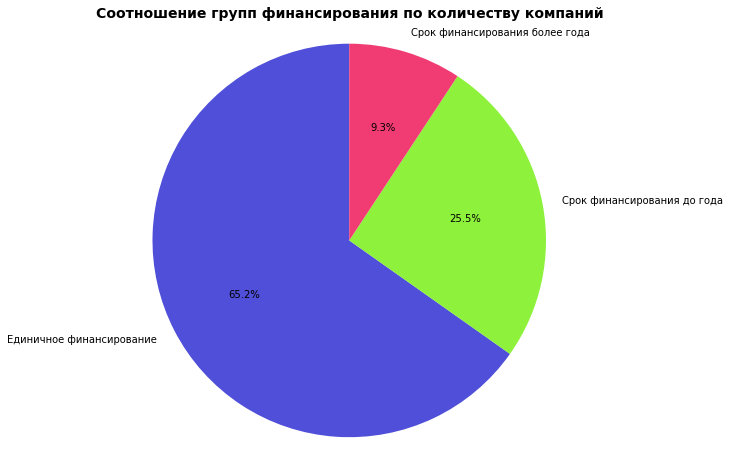

In [42]:
# Создаём круговую диаграмму для соотношения значений
plt.figure(figsize=(10, 8))
labels = ['Единичное финансирование', 'Срок финансирования до года', 'Срок финансирования более года']
colors = ['#4f4fd9', '#8ef13c', '#f13c73']
plt.pie(funding_category_funding_category, labels=labels, autopct='%1.1f%%', colors=colors, 
         startangle=90)
plt.title('Соотношение групп финансирования по количеству компаний', fontsize=14, fontweight='bold')
plt.axis('equal')  
plt.show()

In [43]:
# Выводим доли от общей сумме инвестиций в разрезе категорий
funding_category_total_share = preprocessed_investments_df.groupby('funding_category')['funding_total_usd'].sum()/preprocessed_investments_df['funding_total_usd'].sum()
funding_category_total_share

funding_category
Единичное финансирование          0.309299
Срок финансирования более года    0.618696
Срок финансирования до года       0.072005
Name: funding_total_usd, dtype: float64

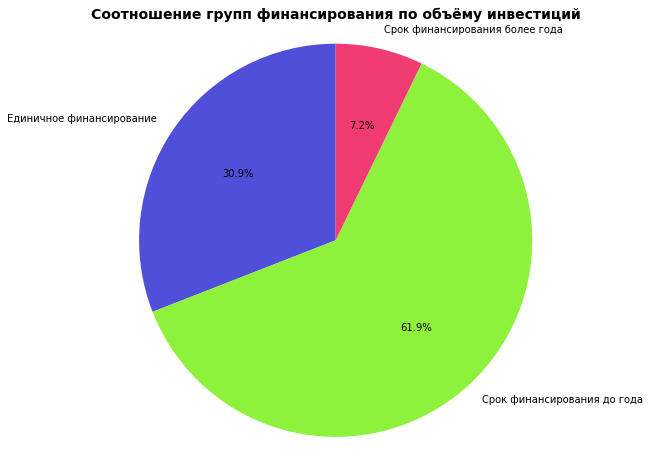

In [44]:
# Создаём круговую диаграмму для соотношения значений
plt.figure(figsize=(10, 8))
labels = ['Единичное финансирование', 'Срок финансирования до года', 'Срок финансирования более года']
colors = ['#4f4fd9', '#8ef13c', '#f13c73']
plt.pie(funding_category_total_share, labels=labels, autopct='%1.1f%%', colors=colors, 
         startangle=90, normalize=False)
plt.title('Соотношение групп финансирования по объёму инвестиций', fontsize=14, fontweight='bold')
plt.axis('equal')  
plt.show()

Анализируя графики можно сделать вывод, что компании со сроком финансирования до одного года занимают около 25% от общего числа стартапов и около 60% инвестиций приходится на них. При этом компании с единичным финансированием состовляют 65% от всех компаний и на их долю приходится более 30% от общего финансирования всего рынка.

### 2 Выделение средних и нишевых сегментов рынка

In [45]:
# Считаем количество компаний по сегментам
market_value_counts = preprocessed_investments_df['market'].value_counts()
market_value_counts = market_value_counts.reset_index()
market_value_counts

,index,market
0,software,5488
1,unknown,3960
2,biotechnology,3761
3,mobile,2725
4,e-commerce,2283
...,...,...
434,gambling,1
435,content creators,1
436,synthetic biology,1
437,credit,1


In [46]:
# Присваиваем компаниям категории сегментов
market_categories = []
for row in market_value_counts['market']:
    if row > 120:
        market_categories.append('Массовый сегмент')
    elif row > 35:
        market_categories.append('Средний сегмент')
    else:
        market_categories.append('Нишевый сегмент')
market_value_counts['market_category'] = market_categories

In [47]:
# Подсчитываем количество сегментов в разрезе категорий
market_value_counts['market_category'].value_counts()

Нишевый сегмент     333
Массовый сегмент     54
Средний сегмент      52
Name: market_category, dtype: int64

In [48]:
# Подсчитываем количество компаний в разрезе категорий
market_category_by_company_count = market_value_counts.groupby('market_category')['market'].sum()
market_category_by_company_count

market_category
Массовый сегмент    44363
Нишевый сегмент      1096
Средний сегмент      3969
Name: market, dtype: int64

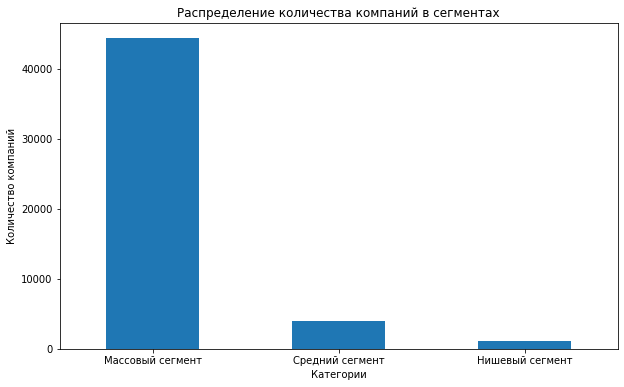

In [49]:
# Выводим диаграмму для визуализации распределения количества компаний в сегментах 
plt.figure(figsize=(10, 6))
market_category_by_company_count.sort_values(ascending=False).plot(kind='bar', legend=False, rot=0)
plt.title('Распределение количества компаний в сегментах')
plt.xlabel('Категории')
plt.ylabel('Количество компаний')
plt.show()

К массовому сегменту относятся 52 отрасли стартапов. При этом в этих отрослях работают 44363, что во много раз больше количества компаний среднего и нишевого сегмента рынка.

In [50]:
# Выводим отралсли компаний, относящиеся к среднему и нишевому сегменту
mid_segments = market_value_counts[market_value_counts['market_category'] == 'Средний сегмент']
niche_segments = market_value_counts[market_value_counts['market_category'] == 'Нишевый сегмент']
mid_segments_list = mid_segments['index'].tolist()
niche_segments_list = niche_segments['index'].tolist()

In [51]:
# Создаём функцию для заполнения значений
def market_category_func (row):
    market_value = row['market']
    if market_value in mid_segments_list:
        return 'mid'
    if market_value in niche_segments_list:
        return 'niche'
    else:
        return market_value

In [52]:
# Применяем функцию
preprocessed_investments_df['market'] = preprocessed_investments_df.apply(market_category_func, axis=1)

In [53]:
# Выводим оставшиеся значения в столбце market
preprocessed_investments_df['market'].unique()

array(['education', 'unknown', 'mid', 'social media',
       'hardware + software', 'biotechnology', 'niche', 'hospitality',
       'enterprise software', 'manufacturing', 'finance', 'design',
       'nonprofits', 'software', 'curated web', 'health care',
       'health and wellness', 'media', 'clean technology',
       'financial services', 'web hosting', 'e-commerce', 'automotive',
       'medical', 'fashion', 'security', 'networking', 'analytics',
       'semiconductors', 'public relations', 'travel', 'consulting',
       'real estate', 'technology', 'music', 'advertising', 'games',
       'mobile', 'sports', 'medical devices', 'internet', 'photography',
       'news', 'messaging', 'search', 'video', 'transportation',
       'marketplaces', 'entertainment', 'saas', 'cloud computing',
       'big data', 'sales and marketing', 'apps', 'social network media',
       'startups'], dtype=object)

## Работа с выбросами и анализ

### 1. Анализируем и помечаем выбросы в каждом из сегментов

In [54]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [55]:
# Выделяем компании с финансированием
filtered_funding_total_df = preprocessed_investments_df[preprocessed_investments_df['funding_total_usd'] > 0]

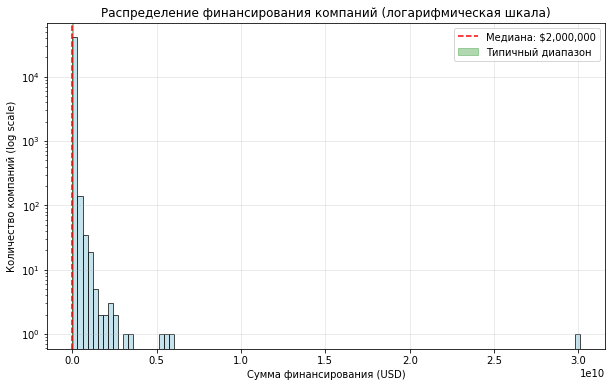

In [56]:
# Создаём график распределения значений funding_total_usd
data = filtered_funding_total_df['funding_total_usd']
# Строим график с логарифмической шкалой
plt.figure(figsize=(10, 6))
plt.hist(data, bins=100, alpha=0.7, color='lightblue', edgecolor='black')
plt.yscale('log')  

plt.title('Распределение финансирования компаний (логарифмическая шкала)')
plt.xlabel('Сумма финансирования (USD)')
plt.ylabel('Количество компаний (log scale)')
plt.grid(True, alpha=0.3)

# Показываем важные границы
q25 = np.percentile(data, 25)
q75 = np.percentile(data, 75)
median = np.percentile(data, 50)

plt.axvline(median, color='red', linestyle='--', label=f'Медиана: ${median:,.0f}')
plt.axvspan(q25, q75, alpha=0.3, color='green', label='Типичный диапазон')

plt.legend()
plt.show()

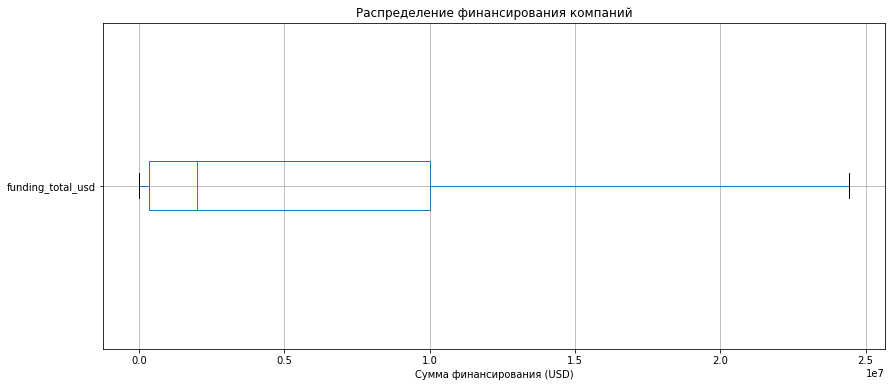

In [57]:
# Создаём диаграмму размаха funding_total_usd
plt.figure(figsize=(14, 6))
filtered_funding_total_df.boxplot(column='funding_total_usd', vert=False, showfliers=False)
plt.title('Распределение финансирования компаний')
plt.xlabel('Сумма финансирования (USD)')
plt.show()

In [58]:
# Выводим описательную статистику funding_total_usd
filtered_funding_total_df['funding_total_usd'].describe()

count         40905.00
mean       15912465.55
std       168682923.56
min               1.00
25%          350000.00
50%         2000000.00
75%        10000000.00
max     30079503000.00
Name: funding_total_usd, dtype: float64

В соответствие с диаграммой размаха типичные (нормальные) значения находятся в пределах "усов" диаграммы. Судя по диаграмме размаха по полю funding_total_usd типичные значения будут находится в интервале от 0 до приблизительно 24 млн. долларов. Значения, находящиеся за пределами данных интервалов, можно считать выбивающимися.

In [59]:
# Считаем Q1 и Q3
Q1 = filtered_funding_total_df['funding_total_usd'].quantile(0.25)
Q3 = filtered_funding_total_df['funding_total_usd'].quantile(0.75)
# Считаем межквартильный размах
IQR = Q3-Q1
# Считаем диапозрн значений
lower_border = Q1 - 1.5 * IQR
upper_border = Q3 + 1.5 * IQR
display('Нижний диапозон значений:', lower_border)
display('Верхнийй диапозон значений:', upper_border)

'Нижний диапозон значений:'

-14125000.0

'Верхнийй диапозон значений:'

24475000.0

In [60]:
# Создаём функцию для заполнения значений
def anomaly_func (row):
    funding_total_value = row['funding_total_usd']
    if funding_total_value < lower_border or funding_total_value > upper_border:
        return True
    else:
        return False

In [61]:
# Применяем функцию для определения компаний с аномальным финансированием
filtered_funding_total_df = filtered_funding_total_df.copy()
filtered_funding_total_df['anomaly_funding_total'] = filtered_funding_total_df.apply(anomaly_func, axis=1)

In [62]:
# Топ 10 сегментов с аномальными значениями
anomaly_markets = filtered_funding_total_df.groupby('market')['anomaly_funding_total'].mean()
anomaly_markets.reset_index().sort_values(by='anomaly_funding_total', ascending=False).head(10)

,market,anomaly_funding_total
44,semiconductors,0.32
6,clean technology,0.28
21,health care,0.27
55,web hosting,0.26
50,technology,0.25
28,medical devices,0.24
5,biotechnology,0.23
51,transportation,0.22
43,security,0.17
7,cloud computing,0.16


В таких сегментах рынка, как semiconductors, clean technology, health care, web hosting, technology более 25% значений относятся к аномальным.	

### 2 Определяем границы рассматриваемого периода, отбрасываем аномалии

In [63]:
# Группируем компании по дате последнего финансирования в 2014 году в разрезе месяцев
focus_year = filtered_funding_total_df[filtered_funding_total_df['last_funding_at'].dt.year == 2014]
focus_year.groupby(focus_year['last_funding_at'].dt.month).agg({'name': 'count'})

,name
last_funding_at,
1,1178
2,947
3,1072
4,1077
5,1036
6,1229
7,1254
8,1064
9,1134


Так как финансирование компаний происходило на протяжении всех месяцов 2014 года, можно судить, что данные за этот год полные.

In [64]:
# Исключаем компании с аномальными значениями финансирования
non_anomaly_funding_total_df = filtered_funding_total_df[filtered_funding_total_df['anomaly_funding_total'] == False]

In [65]:
# Выводим года, где количество раундов финансирования превышает 50
more50_rounds = non_anomaly_funding_total_df.groupby(non_anomaly_funding_total_df['mid_funding_at'].dt.year).agg({'funding_rounds': 'sum'})
more50_rounds = more50_rounds.reset_index()
more50_rounds[more50_rounds['funding_rounds'] >= 50]

,mid_funding_at,funding_rounds
17,1999,52.00
18,2000,130.00
19,2001,70.00
20,2002,99.00
21,2003,125.00
22,2004,183.00
23,2005,949.00
24,2006,1823.00
25,2007,2768.00
26,2008,3466.00


Начиная с 1999 года количество раундов финансирования постоянно превышает 50. В этой связи из датасета необходимо убрать данные ранее 1999 года. 

In [66]:
# Отфильтровываем данные ранее 1999 года
filtered_investments_df = non_anomaly_funding_total_df[non_anomaly_funding_total_df['mid_funding_at'].dt.year >= 1999]
filtered_investments_df['mid_funding_at'].dt.year.unique()

array([2014, 2009, 2013, 2007, 2012, 2010, 2008, 2011, 2005, 2004, 2006,
       2001, 2002, 2000, 2003, 1999])

### 3. Анализ типов финансирования по объёму и популярности

In [67]:
# Создаём список с изучаемыми столбцами
funding_types = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 
    'convertible_note', 'debt_financing', 'angel', 'grant', 
    'private_equity', 'post_ipo_equity', 'post_ipo_debt', 
    'secondary_market', 'product_crowdfunding'
]

In [68]:
# Суммируем финансирование по типам
funding_by_type = {}
for col in funding_types:
    if col in filtered_investments_df.columns:
        funding_by_type[col] = filtered_investments_df[col].sum()

In [69]:
# Соединяем информацию об общем финансировании по типам в единую таблицу
funding_by_type_df = pd.DataFrame(list(funding_by_type.items()), columns=['funding_type', 'total_sum'])
funding_by_type_df.sort_values(by='total_sum', ascending=False)

,funding_type,total_sum
1,venture,108451804548.00
0,seed,9654620122.00
5,debt_financing,5887386251.00
8,private_equity,3190555805.00
6,angel,2645140807.00
3,undisclosed,2311989051.00
7,grant,1900236113.00
9,post_ipo_equity,1097385049.00
4,convertible_note,500481107.00
2,equity_crowdfunding,278717319.00


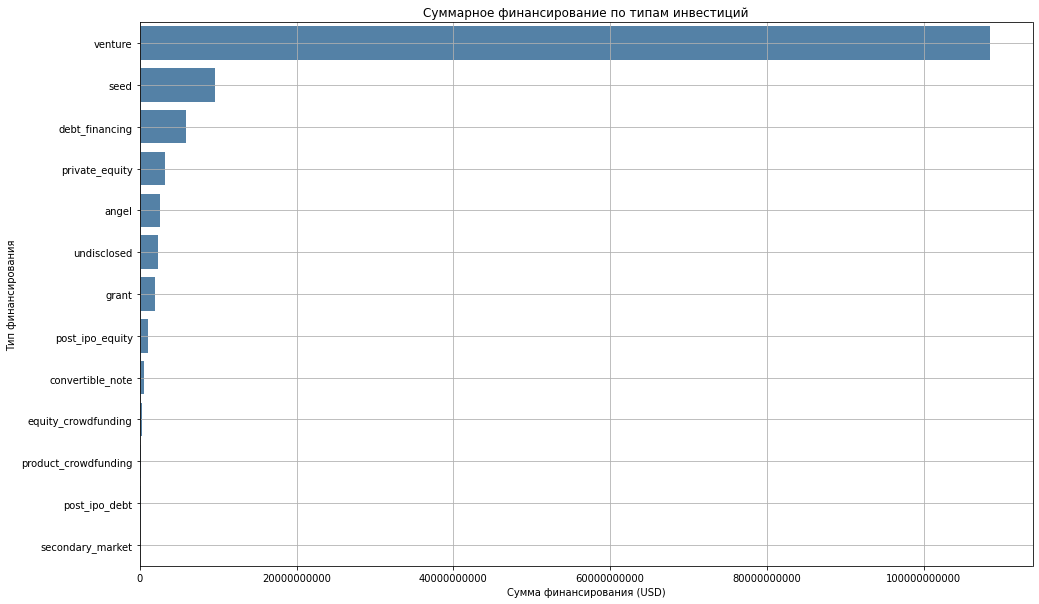

In [70]:
# Создаём линейчатую диаграмму 
funding_by_type_df_sorted = funding_by_type_df.sort_values(by='total_sum', ascending=False)
plt.figure(figsize=(16, 10))
sns.barplot(data=funding_by_type_df_sorted, x='total_sum', y='funding_type', color='steelblue')
plt.title('Суммарное финансирование по типам инвестиций')
plt.xlabel('Сумма финансирования (USD)')
plt.ylabel('Тип финансирования')
plt.ticklabel_format(style='plain', axis='x')
plt.grid()
plt.show()

In [71]:
# Создаём дополнительные столбцы с буливым типом данных для подсчёта количества компаний
filtered_investments_df = filtered_investments_df.copy()
for col in funding_types:
    if col in filtered_investments_df.columns:
        filtered_investments_df[f'{col}_company_count'] = filtered_investments_df[col].astype(bool)

In [72]:
# Создаём список с изучаемыми столбцами
funding_types_bool = [
    'seed_company_count', 'venture_company_count', 'equity_crowdfunding_company_count', 'undisclosed_company_count', 
    'convertible_note_company_count', 'debt_financing_company_count', 'angel_company_count', 'grant_company_count', 
    'private_equity_company_count', 'post_ipo_equity_company_count', 'post_ipo_debt_company_count', 
    'secondary_market_company_count', 'product_crowdfunding_company_count'
]

In [73]:
# Суммируем количество компаний по типам
company_count_by_type = {}
for col in funding_types_bool:
    if col in filtered_investments_df.columns:
        company_count_by_type[col] = filtered_investments_df[col].sum()

In [74]:
# Соединяем информацию о количествах компаний по типам в единую таблицу
company_count_by_type_df = pd.DataFrame(list(company_count_by_type.items()), columns=['funding_type', 'company_count'])
company_count_by_type_df.sort_values(by='company_count', ascending=False)

,funding_type,company_count
1,venture_company_count,18812
0,seed_company_count,13500
5,debt_financing_company_count,3077
6,angel_company_count,2996
7,grant_company_count,1001
3,undisclosed_company_count,839
8,private_equity_company_count,588
2,equity_crowdfunding_company_count,520
4,convertible_note_company_count,509
12,product_crowdfunding_company_count,208


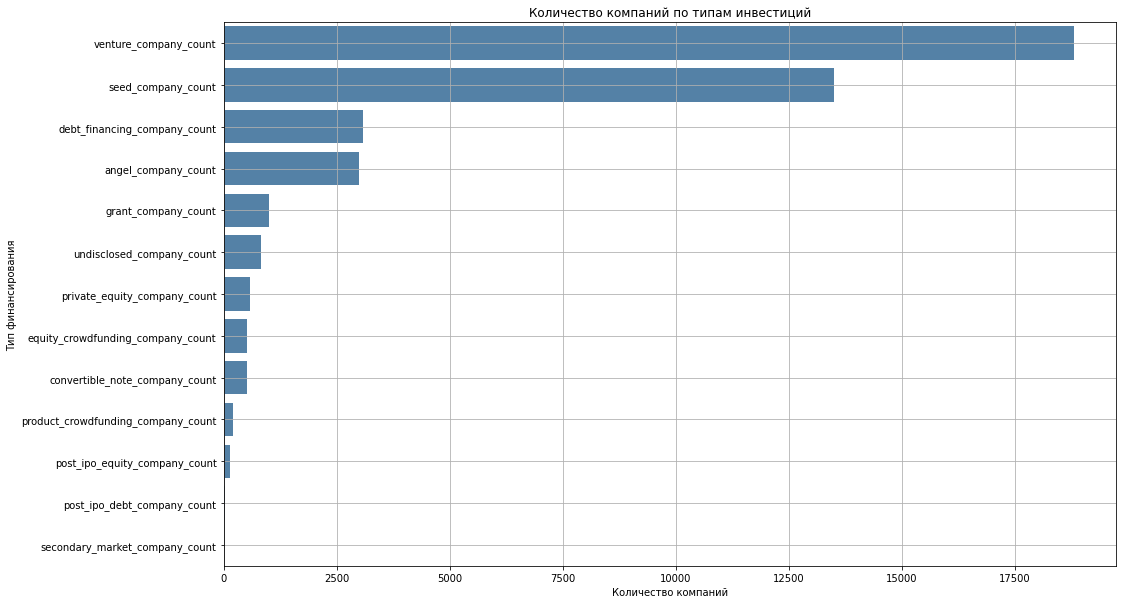

In [75]:
# Создаём линейчатую диаграмму
company_count_by_type_df_sorted = company_count_by_type_df.sort_values(by='company_count', ascending=False)
plt.figure(figsize=(16, 10))
sns.barplot(data=company_count_by_type_df_sorted, x='company_count', y='funding_type', color='steelblue')
plt.title('Количество компаний по типам инвестиций')
plt.xlabel('Количество компаний')
plt.ylabel('Тип финансирования')
plt.ticklabel_format(style='plain', axis='x')
plt.grid()
plt.show()

Тип инвестиций venture привлек финансирования на общую сумму более 108 млрд. долларов, что в разы больше, чем остальные типы инвестиций. Также, большим объемом финансирования выделяются следующие типы: seed, debt_financing, private_equity, angel.
Тип инвестиций venture также является самым популярным видом финансирования для стартапов. 18812 компаний получили финансирование из этого источника. Вместе с этим, популярностью среди инвесторов пользуются такие типы финансирования, как seed, debt_financing, angel, grant.  

In [76]:
# Суммируем возвраты по типам
returns_by_type = {}
for col in funding_types:
    if col in returns_df.columns:
        returns_by_type[col] = returns_df[col].sum()

In [77]:
# Соединяем информацию о возвратах по типам в единую таблицу
returns_by_type_df = pd.DataFrame(list(returns_by_type.items()), columns=['returns_type', 'total_sum'])
returns_by_type_df.sort_values(by='total_sum', ascending=False)

,returns_type,total_sum
1,venture,40578.62
5,debt_financing,4734.85
8,private_equity,3587.33
0,seed,2382.24
6,angel,1509.23
9,post_ipo_equity,1104.96
3,undisclosed,730.88
10,post_ipo_debt,91.03
4,convertible_note,34.79
11,secondary_market,5.20


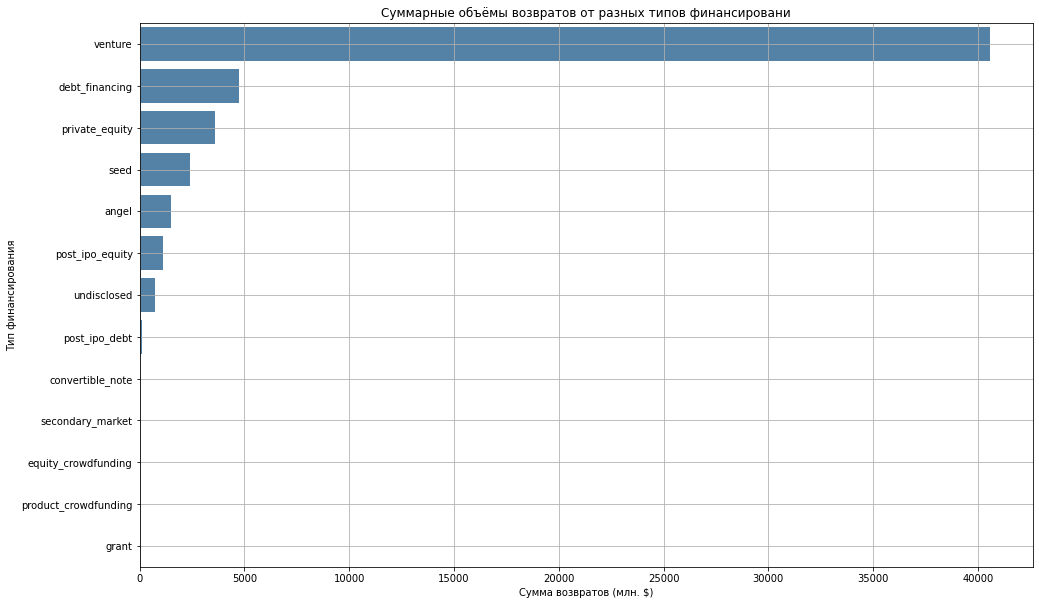

In [78]:
# Создаём линейчатую диаграмму
returns_by_type_df_sorted = returns_by_type_df.sort_values(by='total_sum', ascending=False)
plt.figure(figsize=(16, 10))
sns.barplot(data=returns_by_type_df_sorted, x='total_sum', y='returns_type', color='steelblue')
plt.title('Суммарные объёмы возвратов от разных типов финансировани')
plt.xlabel('Сумма возвратов (млн. $)')
plt.ylabel('Тип финансирования')
plt.grid()
plt.show()

Инвестиции типа venture обладают наибольшей долей возвратов по отношению к другим типам и составляет 40,6 млрд. долларов. Также большой суммой возврата обладают следующие типы инвестиций: debt_financing, private_equity, seed, angel, post_ipo_equity.	

## Анализ динамики

### 1 Динамика предоставления финансирования по годам

In [79]:
# Считаем средний объём одного раунда финансирования
filtered_investments_df['funding_avg_by_rounds'] = filtered_investments_df['funding_total_usd'] / filtered_investments_df['funding_rounds']

In [80]:
# Группируем по годам и считаем медиану среднего раунда
avg_round_by_years = filtered_investments_df.groupby(filtered_investments_df['mid_funding_at'].dt.year)['funding_avg_by_rounds'].median().reset_index()
avg_round_by_years

,mid_funding_at,funding_avg_by_rounds
0,1999,3000000.00
1,2000,3110000.00
2,2001,2368582.00
3,2002,3616666.67
4,2003,1510000.00
5,2004,3375000.00
6,2005,4500000.00
7,2006,3760000.00
8,2007,2786666.67
9,2008,2000000.00


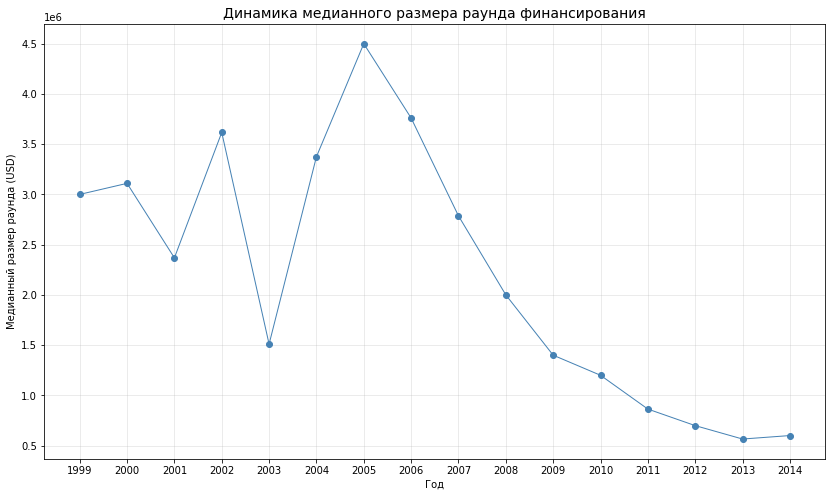

In [81]:
# Выводим график динамики
plt.figure(figsize=(14, 8))
plt.plot(avg_round_by_years['mid_funding_at'], avg_round_by_years['funding_avg_by_rounds'], 
         marker='o', linewidth=1, markersize=6, color='steelblue')
plt.title('Динамика медианного размера раунда финансирования', fontsize=14)
plt.xlabel('Год')
plt.ylabel('Медианный размер раунда (USD)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=0, ticks=avg_round_by_years['mid_funding_at'].unique());

Анализируя график можно наблюдать резкий рост суммы одного раунда финансирования с 2003 по 2005 до пикового значения 4 500 000 долларов, а затем постепенное падение среднией суммы по 2013 года до минимального значения 565 441 долларов. В 2014 наблюдается небольшое увеличение средней суммы за раунд до 600 000 долларов при сохранении тренда на снижение средней суммы. 

In [82]:
# Группируем по годам и считаем общее количество раундов
sum_round_by_years = filtered_investments_df.groupby(filtered_investments_df['mid_funding_at'].dt.year)['funding_rounds'].sum().reset_index()
sum_round_by_years

,mid_funding_at,funding_rounds
0,1999,52.00
1,2000,130.00
2,2001,70.00
3,2002,99.00
4,2003,125.00
5,2004,183.00
6,2005,949.00
7,2006,1823.00
8,2007,2768.00
9,2008,3466.00


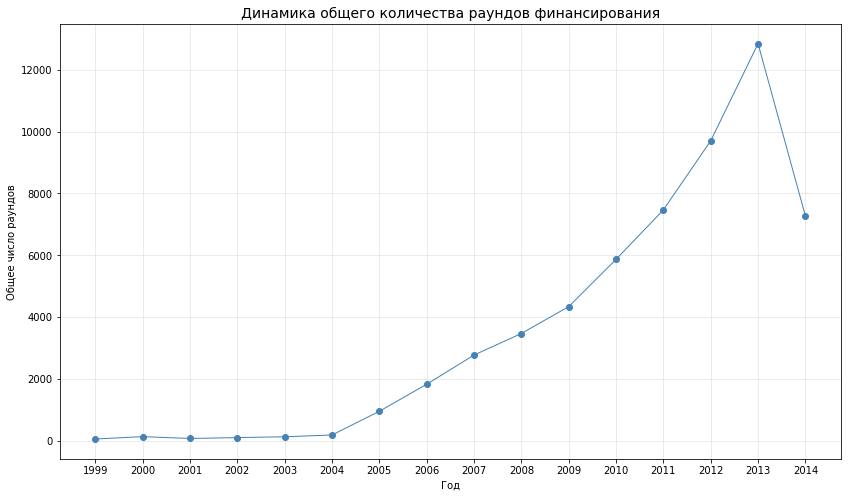

In [83]:
# Выводим график динамики
plt.figure(figsize=(14, 8))
plt.plot(sum_round_by_years['mid_funding_at'], sum_round_by_years['funding_rounds'], 
         marker='o', linewidth=1, markersize=6, color='steelblue')
plt.title('Динамика общего количества раундов финансирования', fontsize=14)
plt.xlabel('Год')
plt.ylabel('Общее число раундов')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=0, ticks=sum_round_by_years['mid_funding_at'].unique());

Анализируя график можно наблюдать рост количества раунда финансирования с 2004 по 2013 год до пикового значения 12843 раундов, а в 2014 году - резкое падение количества раундов до 7272.

### 2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

In [84]:
# Создаем столбец с годом для группировки
filtered_investments_df['year_mid_funding'] = filtered_investments_df['mid_funding_at'].dt.year

In [85]:
# Создаем сводную таблицу
pivot_table = filtered_investments_df.pivot_table(
    values='funding_total_usd',
    index='year_mid_funding',
    columns='market',
    aggfunc='sum',
    fill_value=0
)
pivot_table

market,advertising,analytics,apps,automotive,big data,biotechnology,clean technology,cloud computing,consulting,curated web,...,social network media,software,sports,startups,technology,transportation,travel,unknown,video,web hosting
year_mid_funding,,,,,,,,,,,,,,,,,,,,,
1999,350000,10774916,0,0,0,0,0,0,115200,9250000,...,0,50034643,0,0,6000000,0,0,9432055,0,3600000
2000,14470000,14822803,0,0,0,0,0,11500000,4500000,32200000,...,0,31732640,0,0,0,0,50230,13039560,0,155000
2001,8778321,0,0,0,0,0,0,0,0,305000,...,0,50086279,0,0,22160000,6779357,0,51540483,0,15000000
2002,24500000,7500000,0,0,0,0,0,0,0,22950000,...,0,125026395,200000,0,11000000,0,0,44606286,0,0
2003,10500000,3840000,0,4530000,0,42031178,2175000,0,0,48871350,...,0,66086037,0,0,0,15000000,0,4155202,5000000,0
2004,6000000,3000000,0,0,0,45119644,19427954,0,0,131850000,...,0,140823795,0,0,1750000,22600000,10230000,83428435,14704000,27000000
2005,101696022,79014044,0,22500000,0,290763582,19420000,0,64862000,84650000,...,20500000,1147861822,1882200,0,20728425,0,27830000,121621681,6470551,314732632
2006,222727774,139701311,1310600,12660000,0,450524428,25870000,9951809,67930188,344157822,...,20245100,1822635854,7000000,0,22791000,17400000,11700000,255542109,55321772,308243433
2007,503704331,48829000,20250000,37712601,7780000,776095385,228545046,20354343,103846345,615316482,...,53404021,1892676357,42401580,0,16990209,5207611,55001724,57532468,108500644,124169223


In [86]:
# Находим сегменты где 2014 > 2013
growing_segments = []
for segment in pivot_table.columns:
    if pivot_table.loc[2014, segment] > pivot_table.loc[2013, segment]:
        growing_segments.append(segment)

In [87]:
# Удаляем ненужные сегменты
growing_segments.remove('mid')

In [88]:
# Удаляем ненужные сегменты
growing_segments.remove('niche')

In [89]:
# Удаляем ненужные сегменты
growing_segments.remove('unknown')

In [90]:
# Проверяем оставшиеся сегменты
growing_segments

['apps',
 'financial services',
 'internet',
 'medical',
 'medical devices',
 'nonprofits',
 'real estate',
 'saas',
 'sports',
 'startups',
 'technology',
 'video']

In [91]:
# Выводим сегменты, где 2014 > 2013
pivot_table_growing_segments = pivot_table[growing_segments]
pivot_table_growing_segments

market,apps,financial services,internet,medical,medical devices,nonprofits,real estate,saas,sports,startups,technology,video
year_mid_funding,,,,,,,,,,,,
1999,0,0,0,0,0,0,250000,0,0,0,6000000,0
2000,0,0,10000000,24000000,8500000,6500000,2500000,0,0,0,0,0
2001,0,0,0,0,0,0,0,0,0,0,22160000,0
2002,0,0,1100000,0,0,0,5275000,2000000,200000,0,11000000,0
2003,0,0,0,0,2043272,0,6292200,0,0,0,0,5000000
2004,0,0,10500000,0,0,0,0,0,0,0,1750000,14704000
2005,0,15183352,1775000,11090000,0,17051520,250000,5240000,1882200,0,20728425,6470551
2006,1310600,0,21405000,20250000,3500000,12880000,22080000,4791121,7000000,0,22791000,55321772
2007,20250000,21400000,4495379,2100000,0,200000,56220000,74252585,42401580,0,16990209,108500644


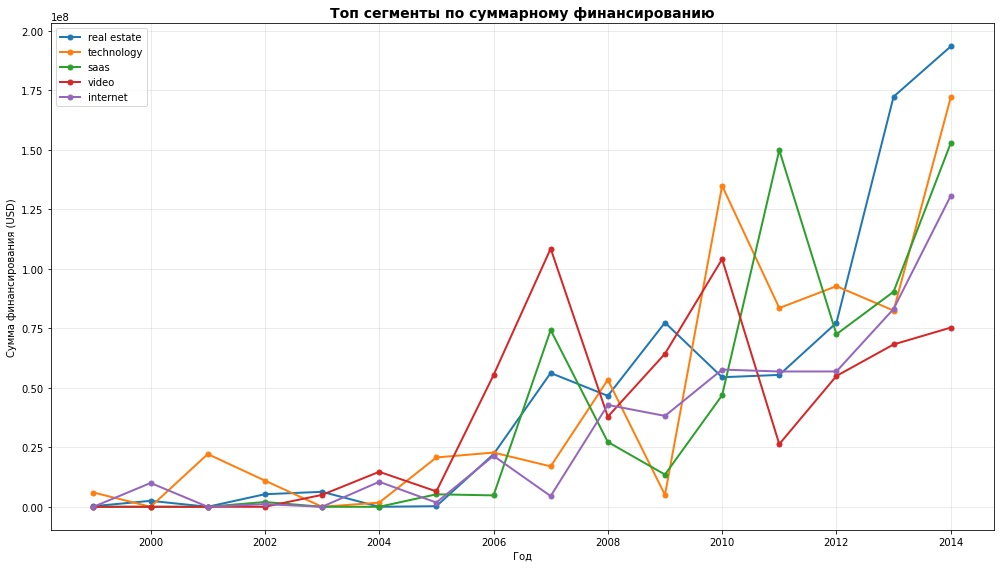

In [92]:
# Создаём график для топ-5 сегметов
top_segments = pivot_table_growing_segments.sum().nlargest(5).index
top_data = pivot_table_growing_segments[top_segments]

plt.figure(figsize=(14, 8))
for segment in top_data.columns:
    plt.plot(top_data.index, top_data[segment], 
             marker='o', linewidth=2, markersize=5, label=segment)

plt.title('Топ сегменты по суммарному финансированию', fontsize=14, fontweight='bold')
plt.xlabel('Год')
plt.ylabel('Сумма финансирования (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

В результате анализа выделено топ-5 сегментов (real estate, technology, saas, video, internet) которые демонстрируют тенденцию на рост.

### 3 Годовая динамика доли возвращённых средств по типам финансирования

In [93]:
# Выделяем год для оригинального предобработанного датафрейма
origin_preprocessed_investments_df['year_mid_funding'] = origin_preprocessed_investments_df['mid_funding_at'].dt.year
# Группируем общую сумму по изучаемым типам инвестиций по годам
types_studied = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']
investments_type_by_year = origin_preprocessed_investments_df.groupby('year_mid_funding')[types_studied].sum()
investments_type_by_year = investments_type_by_year.tail(15)
investments_type_by_year

,venture,debt_financing,private_equity,seed,angel
year_mid_funding,,,,,
2000,2005037824.00,68650000.00,168000000.00,41831820.00,26086333.00
2001,1200219807.00,64829217.00,148486379.00,26398965.00,1000000.00
2002,1070443969.00,215309671.00,1153441877.00,18226724.00,8000000.00
2003,2024470184.00,21301000.00,27735971.00,18261225.00,48026240.00
2004,3739919785.00,166190070.00,173000000.00,31771371.00,11563741.00
2005,12604292866.00,750339691.00,1358152164.00,52081198.00,64467827.00
2006,23421689493.00,3224687727.00,2434829635.00,103650830.00,89898898.00
2007,38561112399.00,2887082096.00,8304915409.00,291031899.00,261202441.00
2008,52851190352.00,5275522220.00,10900263419.00,358576739.00,276424613.00


In [94]:
# Выбираем изучаемые столбцы для returns_df
returns_df_5types = returns_df[['year', 'venture', 'debt_financing', 'private_equity', 'seed', 'angel']]
returns_df_5types = returns_df_5types.set_index('year')
returns_df_5types

,venture,debt_financing,private_equity,seed,angel
year,,,,,
2000,55.40,8.66,0.00,16.70,6.43
2001,23.49,4.49,0.00,2.88,1.18
2002,209.42,3.42,1.51,6.59,3.41
2003,233.86,1.09,1.62,7.74,3.41
2004,555.90,13.55,2.19,9.93,9.18
2005,2628.92,35.09,2.40,26.60,31.06
2006,3100.18,113.21,16.67,61.81,47.75
2007,3585.37,125.68,88.81,70.41,164.51
2008,2717.02,397.54,130.38,89.72,102.83


In [95]:
# Выводим доли возврата средств по годам
share_returns_df = (returns_df_5types * 1000000) / ((investments_type_by_year) + 1e-60)
share_returns_df

,venture,debt_financing,private_equity,seed,angel
year,,,,,
2000,0.03,0.13,0.00,0.40,0.25
2001,0.02,0.07,0.00,0.11,1.18
2002,0.20,0.02,0.00,0.36,0.43
2003,0.12,0.05,0.06,0.42,0.07
2004,0.15,0.08,0.01,0.31,0.79
2005,0.21,0.05,0.00,0.51,0.48
2006,0.13,0.04,0.01,0.60,0.53
2007,0.09,0.04,0.01,0.24,0.63
2008,0.05,0.08,0.01,0.25,0.37


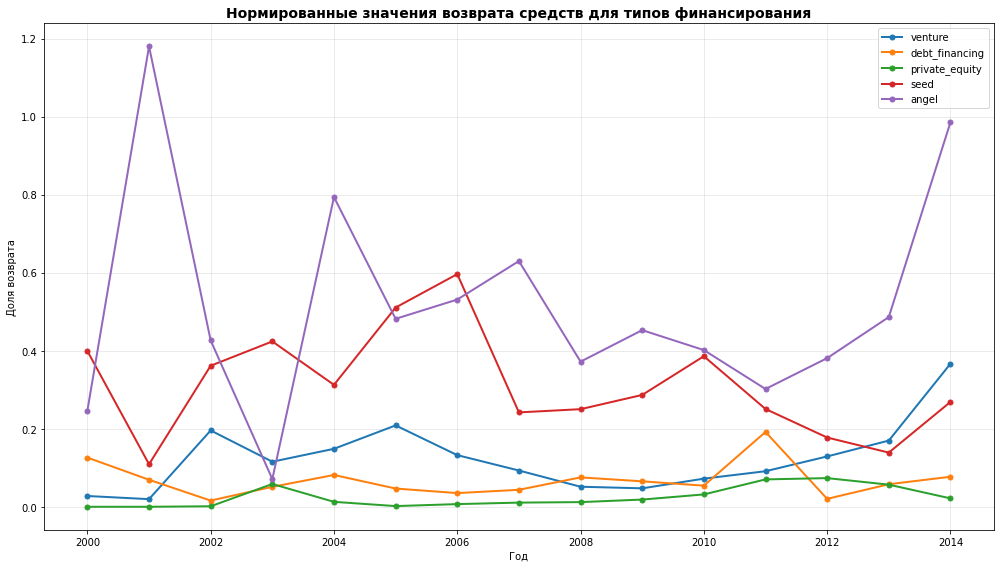

In [96]:
# Создаём график
plot_types_data = share_returns_df

plt.figure(figsize=(14, 8))
for segment in plot_types_data:
    plt.plot(plot_types_data.index, plot_types_data[segment], 
             marker='o', linewidth=2, markersize=5, label=segment)

plt.title('Нормированные значения возврата средств для типов финансирования', fontsize=14, fontweight='bold')
plt.xlabel('Год')
plt.ylabel('Доля возврата')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Анализ графиков показал отсутствие типов финансирований с устойчивым ростом возврата средств.


## Итоговый вывод и рекомендации

Исследование проводилось в целях изучения закономерности финансирования стартапов и оценки перспективы выхода на рынок с покупкой и развитием компаний. В ходе исследования проанализировано 49 428 строк данных об инвестициях в компании. Данные включали в себя информацию об отрослях компаний, основных источниках инвестиций, количествах раундов и датах финансирования стартапов. Также дополнительно были изучены суммы возвратов инвестиций по различным типам финансирования.

В ходе исследования была проделана следующая работа:

1. Предобработка данных
2. Инжиниринг признаков
3. Анализ выбросов и статистики
4. Анализ динамики

По итогам исследования можно выделить следующие:

**Рекомендация по инвестиционной стратегии**

Оптимальной отраслю для инвестиций является **Real Estate**. Сегмент Real Estate входит в топ-5 сегментов, демонстрирующих устойчивый рост, а также относится к массовому сегменту рынка и показывает стабильную динамику. 

Рекомендуемым типом финансирования является **Venture**. Данный тип является лидером по объему привлеченных средств (более 108 млрд. долларов) и по доле возвратов (40,6 млрд долларов). Через этот источник получили финансирование 18 812 компаний, что указывает о его безоговорочной популярности среди инвесторов. 

**Основные выводы исследования**

- Тип финансирования Venture демонстрирует лидерство по показателям объём, возвраты и популярность, однако не показывает устойчивого роста возвратов. 
- Резкое падение количества раундов финансирования с 2013 по 2014 год при тенденции на рост финансирования.
- На долю компаний со сроком финансирования до одного года приходится большая часть инвестиций, при этом такие компании занимают около 25% от общего числа стартапов.
- Массовые сегменты концентрирует основную долю рынка и инвестиций.